# Dataset 8 — Breast Cancer Wisconsin (Original)

## Descripción general
Este dataset clínico es un estándar histórico en Machine Learning, obtenido de los Hospitales de la Universidad de Wisconsin. Contiene muestras de tejido extraídas mediante biopsias por aspiración con aguja fina. Evalúa nueve características morfológicas celulares (como la uniformidad del tamaño, forma y adhesión marginal) puntuadas en una escala del 1 al 10.

## Objetivo
**Problema de Clasificación Binaria Médica** — Clasificar una muestra de tejido como **Benigna** (`class = 0`) o **Maligna** (`class = 1`) para asistir en el diagnóstico temprano del cáncer de mama.

## Estructura original
- **Archivo:** `breast-cancer-wisconsin.data` (699 instancias).
- **Columnas:** 10 atributos de entrada + 1 variable objetivo (`class`).
- **Naturaleza:** Originalmente codificaba los tumores benignos con `2` y malignos con `4`.

## Tratamiento aplicado y Justificaciones

### 1. Eliminación de Identificadores (Data Leakage / Ruido)
Se identificó que la primera columna (`id_number`) correspondía al número de muestra o código del paciente. 
- **Acción:** Fue eliminada inmediatamente. 
- **Justificación:** Los números de identificación no tienen correlación biológica con el desarrollo de un tumor. Mantener esta columna forzaría al algoritmo a memorizar IDs de pacientes en lugar de aprender patrones morfológicos generalizables.

### 2. Limpieza de Valores Faltantes Ocultos
La columna **Bare Nuclei** (Núcleos Desnudos) contenía 16 registros marcados con el símbolo `'?'`.
- **Acción:** Se forzaron a valores nulos (NaN) y se imputaron utilizando la **mediana** de dicha columna. 
- **Justificación:** Al tratarse de una escala ordinal (1-10) y no una métrica continua pura, la mediana es estadísticamente más robusta que el promedio, ya que no genera números decimales inexistentes en la escala biológica original.

### 3. Mapeo Binario de la Variable Objetivo
Para habilitar el uso de algoritmos de clasificación basados en regresión logística (que utilizan funciones matemáticas como la Sigmoide con salidas entre 0 y 1), las etiquetas fueron transformadas:
- **Benigno (2)** $\rightarrow$ **0**
- **Maligno (4)** $\rightarrow$ **1**

### 4. Balanceo de Clases (Undersampling)
El dataset presentaba una distribución asimétrica (aproximadamente 65.5% benignos frente a 34.5% malignos). 
- **Acción:** Se aplicó **Undersampling aleatorio** a la clase mayoritaria (benignos) para igualarla a la minoritaria.

### 5. Preparación Matemática y División
- **Partición:** División del 80% para el cálculo de gradientes (entrenamiento) y 20% aislado para validación final.
- **Normalización Z-score:** Se estandarizaron las características para optimizar la convergencia del algoritmo.
- **Término de Bias:** Adición de la columna de unos ($X_0 = 1$) para el cálculo de la intersección.

## Resultado final
| Métrica | Antes | Después |
|--|-------|---------|
| **Filas** | 699 | 482 (Balanceadas 50/50) |
| **Columnas** | 11 | 10 (incluyendo bias) |
| **Valores faltantes** | 16 | 0 |
| **Balance de clases** | 65.5% / 34.5% | 50.0% / 50.0% |

## ¿Está balanceado?
**Sí, de manera estricta.** Se logró un equilibrio perfecto (241 muestras benignas y 241 malignas). En un contexto médico, esto es imperativo. Un modelo entrenado con datos desbalanceados podría desarrollar un sesgo estadístico hacia predecir "benigno" simplemente por ser el caso más frecuente. En la medicina, un "Falso Negativo" (decirle a alguien que está sano cuando tiene cáncer) es un error crítico que el balanceo ayuda a mitigar.

Shape original: (699, 11)

Distribución de clases original (2=Benigno, 4=Maligno):
class
2    458
4    241
Name: count, dtype: int64

Shape tras eliminar 'id_number': (699, 10)

Ninguna columna superó el 50% de nulos.
NaN totales restantes: 0

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
class
1    241
0    241
Name: count, dtype: int64

 DESCRIPCIÓN DEL DATASET PREPARADO 
Nombre: Breast Cancer Wisconsin (Original)
Problema: Clasificación Binaria (Cáncer)
Filas listas: 482
Columnas predictoras: 9

Dataset guardado como 'BreastCancer_preparado.csv'
\INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN 
Tamaño X_train_norm: (385, 10)
Tamaño X_test_norm:  (97, 10)


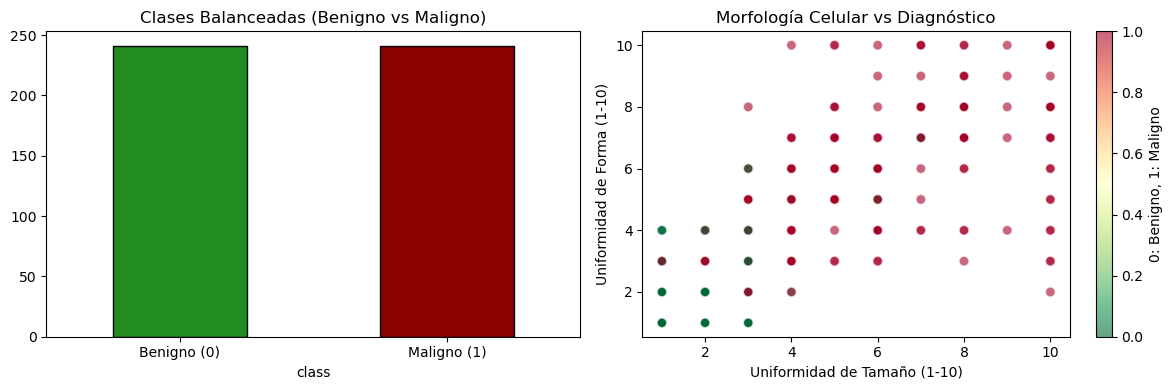

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 8: Breast Cancer (Clasificación)

# 1. CARGAR
ruta_cancer = r"C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset8\breast+cancer+wisconsin+original\breast-cancer-wisconsin.data"

# Nombres de columnas según la documentación oficial
columnas = ['id_number', 'clump_thickness', 'uniformity_size', 'uniformity_shape', 
            'marginal_adhesion', 'epithelial_size', 'bare_nuclei', 'bland_chromatin', 
            'normal_nucleoli', 'mitoses', 'class']

# Cargamos indicando que los '?' son valores nulos reales
df = pd.read_csv(ruta_cancer, names=columnas, na_values='?', skipinitialspace=True)

print("Shape original:", df.shape)
print("\nDistribución de clases original (2=Benigno, 4=Maligno):")
print(df['class'].value_counts())

# 2. ELIMINAR COLUMNAS INÚTILES
# El id_number es solo un código de hospital, no sirve para predecir el cáncer
df = df.drop(columns=['id_number'])
print("\nShape tras eliminar 'id_number':", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
if cols_muchos_nulos:
    df = df.drop(columns=cols_muchos_nulos)
else:
    print("\nNinguna columna superó el 50% de nulos.")

# 4. IMPUTAR NaN RESTANTES
# La columna 'bare_nuclei' tiene 16 nulos. Imputamos con mediana por ser escala ordinal.
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if col == 'class': continue
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("NaN totales restantes:", df.isnull().sum().sum())

# 5. CODIFICACIÓN (Mapeo de Clase Binario)
# Convertimos: Benigno (2) -> 0 | Maligno (4) -> 1
df['class'] = df['class'].map({2: 0, 4: 1})

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['class'] == 0] # Casos benignos
clase_minoritaria = df[df['class'] == 1] # Casos malignos

# Igualamos la clase mayoritaria a la cantidad de casos malignos
clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])

# Mezclar aleatoriamente para que el modelo no aprenda en bloque
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribución después del balanceo:")
print(df['class'].value_counts())

# 7. MOVER TARGET AL FINAL
cols = [c for c in df.columns if c != 'class'] + ['class']
df = df[cols]

# 8. RESUMEN FINAL
print("\n DESCRIPCIÓN DEL DATASET PREPARADO ")
print(f"Nombre: Breast Cancer Wisconsin (Original)")
print(f"Problema: Clasificación Binaria (Cáncer)")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas predictoras: {df.shape[1] - 1}")

# 9. GUARDAR
df.to_csv('BreastCancer_preparado.csv', index=False)
print("\nDataset guardado como 'BreastCancer_preparado.csv'")

# 10. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
print("\INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ")

# .astype(float) para evitar errores con las matrices matemáticas
X = df.drop('class', axis=1).astype(float).values
y = df['class'].values

m = len(y)
limite = int(m * 0.8)

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual de normalización (Z-Score)
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 
    return (X_data - mu) / sigma, mu, sigma

# Normalizar con base en entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos (sesgo/intercepto)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 11. GRÁFICAS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['class'].value_counts().plot(kind='bar', color=['forestgreen', 'darkred'], edgecolor='black')
plt.title("Clases Balanceadas (Benigno vs Maligno)")
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'], rotation=0)

plt.subplot(1, 2, 2)
# Gráfica de dispersión: Uniformidad de Tamaño vs Forma
scatter = plt.scatter(df['uniformity_size'], df['uniformity_shape'], c=df['class'], cmap='RdYlGn_r', alpha=0.6, edgecolors='w', s=50)
plt.title("Morfología Celular vs Diagnóstico")
plt.xlabel("Uniformidad de Tamaño (1-10)")
plt.ylabel("Uniformidad de Forma (1-10)")
plt.colorbar(scatter, label='0: Benigno, 1: Maligno')

plt.tight_layout()
plt.show()